In [3]:
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt
import math

from os import listdir
from os.path import isfile, join

from utils.data_parsing_tools import get_lot
from utils.general_tools import pd_to_param_holder
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.modeling_tools import perform_modeling_linear
from utils.regression_tools import forecast_test_linear
from utils.display_tools import load_best_forecasts, display_predictions

In [2]:
3888 + 3888 + 648 + 5184 + 1728

15336

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Display the forecasts and save them properly into a table

In [49]:
data = pickle.load(open("../saves_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

In [58]:
d = data["Moehne"]["desc1"]
d = (d - d.min()) /  ( d.max() - d.min())
d = d[d.var().sort_values().index]

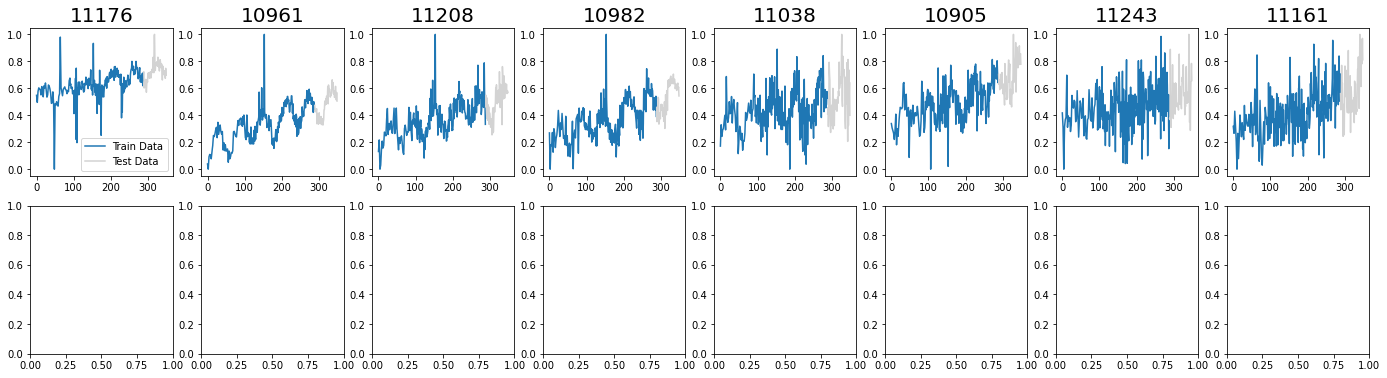

In [59]:

row_length = 8

rows = int(len(d.columns)/ row_length) + 1
fig, axs = plt.subplots(rows, row_length, figsize=(3 * row_length, 3 * rows))
axs = axs.reshape(-1)
for n, key in enumerate(d.columns):
    train = d.loc[d.index.year < 2020, key].interpolate()
    test = d.loc[d.index.year >= 2020, key].interpolate()

    axs[n].plot(np.arange(len(train)), train.values, label="Train Data")
    axs[n].plot(np.arange(len(train), len(train)+ len(test)), test, label="Test Data", color="lightgrey")

    axs[n].set_title(key, fontsize=20)
axs[0].legend()


In [5]:
d = data[loc][direction]
y_ = d.loc[d.index.year == 2020]

### Finally: Full search always interaction effect

In [6]:
model_spec, forecasts = load_best_forecasts("results/full_search_interaction_f", direction="lot")
model_spec

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,...,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
linear,Radial,0.014741,0.002966,0.047009,1,NaN,NaN,2,[0],[0 1 2],...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear
forest,Radial,0.017299,-0.005585,0.046552,2,NaN,NaN,2,[0 1 2],[0 1 2],...,1,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,forest
ada,Radial,0.014097,-0.027486,0.045406,2,NaN,NaN,2,[0],[0 1 2],...,1,linear,250.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
sarimax,Radial,0.049762,0.042520,0.049068,1,1.0,1.0,2,[0],[0 1],...,1,NaN,NaN,NaN,NaN,0.01706,0.000771,0.107731,-9901.71942,sarimax


### Rebuild model

In [7]:
# some ugly refractor because of loading: 
for y in ["T", "STAU"]:
    stack = []
    for x in model_spec.index:
            stack.append(np.array(model_spec.loc[x,  y][1:-1].split(" ")).astype(int))
    model_spec[y] = stack

In [8]:
model_spec["Index"] = model_spec.index
combo = pd_to_param_holder(model_spec, "linear")

In [ ]:
endog = data.asfreq("d")

# 1. ' THIS IS THE ONLY THING THAT HAS TO BE CHANGED HERE IF OTHER DATA IS USED.
exog_prep = build_specific_ds(
    endog,
    exogs,
    future=False,
    fourier_order=combo.f,
    external_timesteps=combo.ex,
    mean_period=combo.mean,
    interaction=combo.interaction
)

In [9]:
(train,
test,
max_data,
min_data,
trend,
seasonality,
test_trend,
test_seasonality) = (
full_preprocessing_pipeline(data["Moehne"]["lot"], exogs["Moehne"], combo, model_search=False)
)

/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/data_processing_tools.py:219: FutureWarning: Dropping of nuisance columns in rolling operations is deprecated; in a future version this will raise TypeError. Select only valid columns before calling the operation. Dropped columns were Index(['datetime'], dtype='object')
  exog_stau = exog.rolling(mean_period[1], closed="left").mean()
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
